**PRCP-1000 Portuguese Bank Marketing**

**Domain Analysis:**
The portuguese bank marketing needs to optimize their direct marketing(phone) campaigns for term deposit products.Here,the challenge is to identify which customes are most likely to subscribe to a term deposit, it reduce marketingcosts by targeting high-probability customers to improve conversion rates through better customer segmentation.

**Objective:**
The primary goal of this project is to predict whether a client will subscribe to a term deposit(yes/no)and also other goals are to understand key factors influencing customer decisions,optimize contact strategies(timing,frequency),and reduce wasted effort on unlikely converters

In [ ]:
# Import all the libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:
# Load the data
data = pd.read_csv("/content/bank-additional-full.csv",sep=';')

**Basic Cehcks**

In [ ]:
# Shape of data
data.shape

(41188, 21)

In [ ]:
# First 5 rows of the data
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
# Last 5 rows of the data
data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [ ]:
# Check the column names
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [ ]:
#Check the dtypes of target column
data['y'].dtype

dtype('O')

In [ ]:
# Check for duplicates
data.duplicated().sum()

np.int64(12)

In [ ]:
# Check for null values
data.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
# Check the info of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
# Check the statistical summary of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


**Exploratory Data Analysis(EDA)**

**Univariate Analysis**

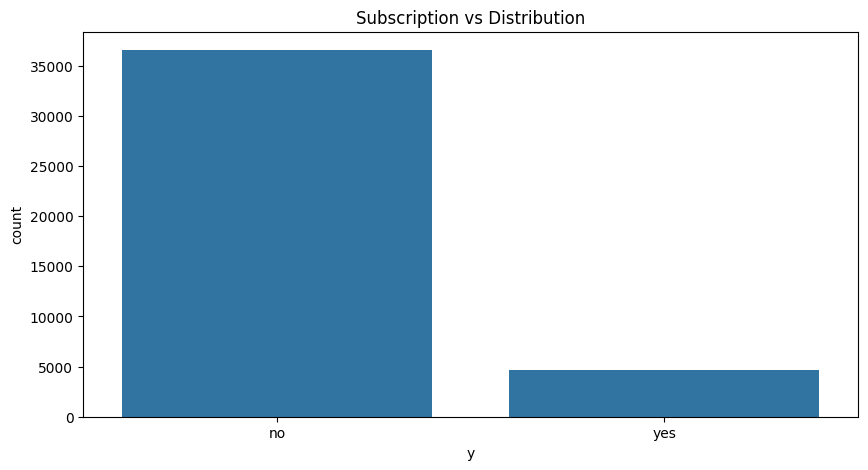

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='y',data=data)
plt.title("Subscription vs Distribution")
plt.show()

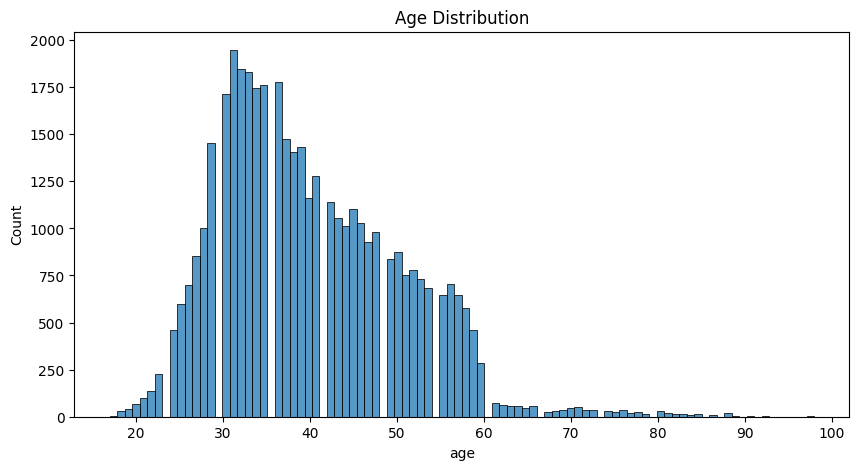

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(x='age',data=data)
plt.title("Age Distribution")
plt.show()

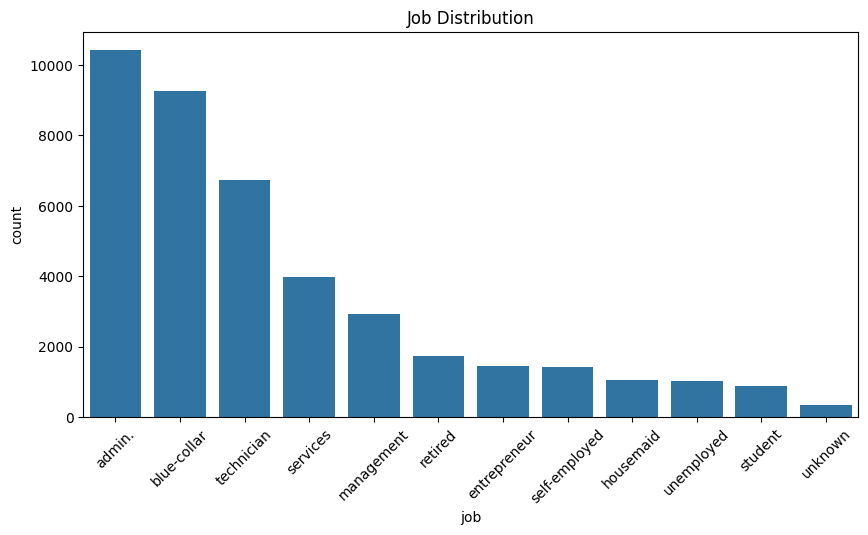

In [ ]:
plt.figure(figsize=(10,5))
job_order = data['job'].value_counts().index
sns.countplot(x='job',data=data,order=job_order)
plt.xticks(rotation=45)
plt.title("Job Distribution")
plt.show()

**Bivariate Analysis**

<Figure size 1000x500 with 0 Axes>

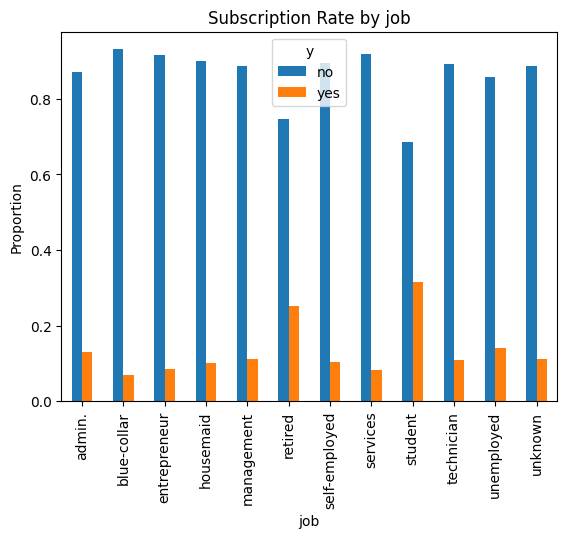

<Figure size 1000x500 with 0 Axes>

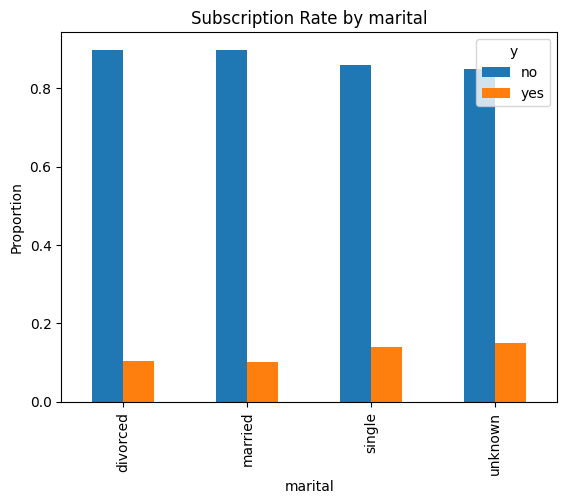

<Figure size 1000x500 with 0 Axes>

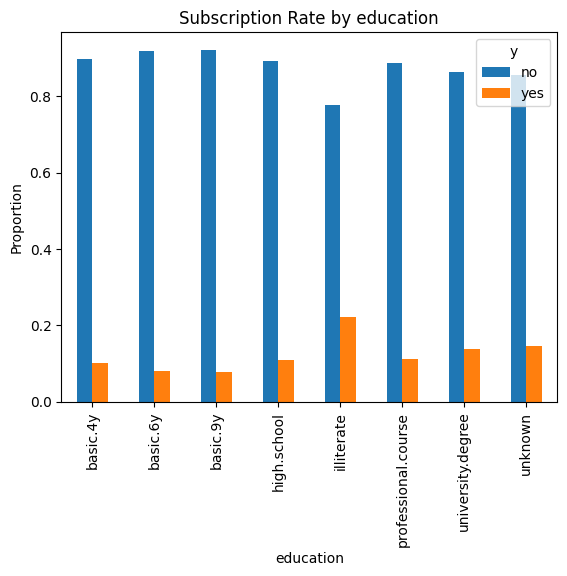

<Figure size 1000x500 with 0 Axes>

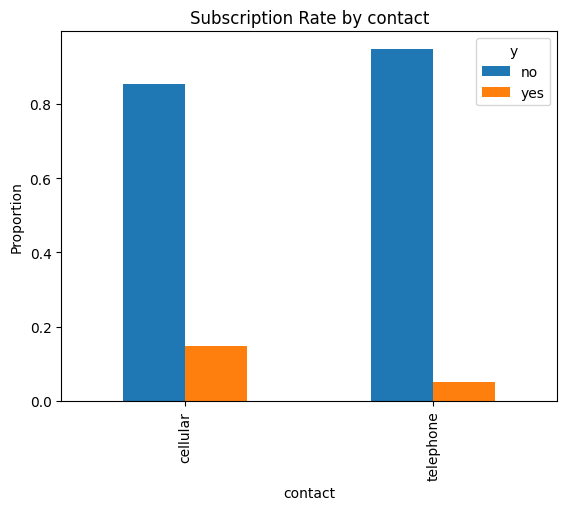

<Figure size 1000x500 with 0 Axes>

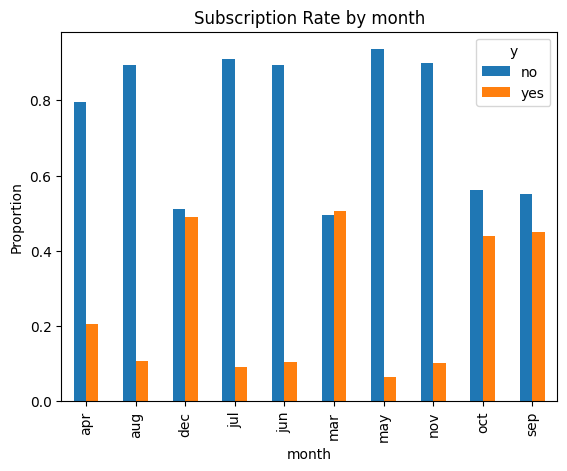

<Figure size 1000x500 with 0 Axes>

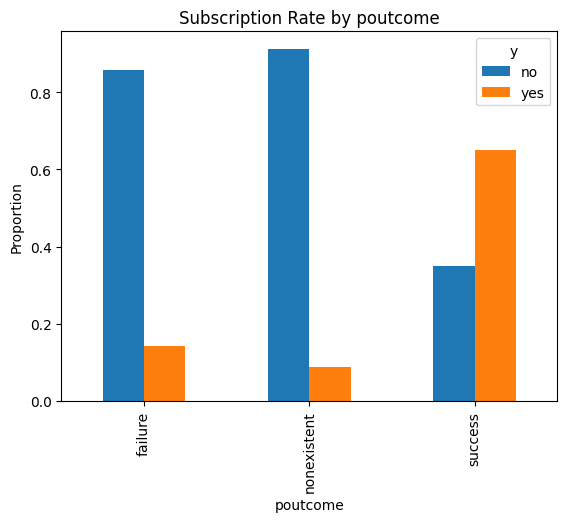

In [ ]:
for col in['job','marital','education','contact','month','poutcome']:
  plt.figure(figsize=(10,5))
  pd.crosstab(data[col],data['y'],normalize='index').plot(kind='bar')
  plt.title(f'Subscription Rate by {col}')
  plt.ylabel("Proportion")
  plt.show()

**Correlation Heatmap**

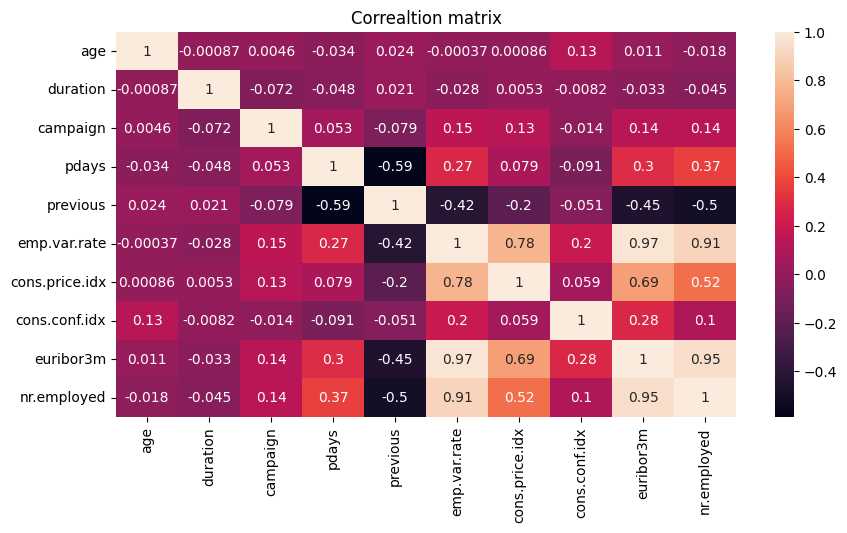

In [ ]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(10,5))
sns.heatmap(data[num_cols].corr(),annot=True)
plt.title("Correaltion matrix")
plt.show()

**Feature Target Separation**

In [ ]:
# Divide the data into x and y
X = data.drop('y',axis=1)
y = data['y']

In [ ]:
# Split the data into train test split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,
    random_state=42
)

**Winsorization**

In [ ]:
def cap_outliers_iqr(X_train_df, X_test_df):
  X_train_copy = X_train_df.copy()
  X_test_copy = X_test_df.copy()
  numerical_cols = X_train_copy.select_dtypes(include=['int64','float64']).columns
  for col in numerical_cols:
    Q1 = X_train_copy[col].quantile(0.25)
    Q3 = X_train_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_train_copy[col] = np.clip(X_train_copy[col],lower_bound,upper_bound)
    X_test_copy[col] = np.clip(X_test_copy[col],lower_bound,upper_bound)
  return X_train_copy, X_test_copy

**Preprocessing**

In [ ]:
categorical_cols = X_train.select_dtypes(include=['object','category']).columns
numerical_cols = X_train.select_dtypes(include=['int64','float64']).columns
numeric_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer),
    ('scaler',StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',numeric_transformer,numerical_cols),
    ('cat',categorical_transformer,categorical_cols)
])

**Model Building**

In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000,class_weight='balanced'),
    "Decision Tree" : DecisionTreeClassifier(random_state=42),
    "Random Forest" : RandomForestClassifier(n_estimators=200,random_state=42),
    "KNN" : KNeighborsClassifier(),
    "SVM" : SVC(class_weight='balanced'),
    "Gradient Boosting" : GradientBoostingClassifier(n_estimators=200,random_state=42)
}

In [ ]:
results=[]
numerical_cols_new = X_train.select_dtypes(include=['int64','float64']).columns
categorical_cols_new = X_train.select_dtypes(include=['object','category']).columns
numeric_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])
preprocessor_new = ColumnTransformer(transformers=[
    ('num',numeric_transformer,numerical_cols_new),
    ('cat',categorical_transformer,categorical_cols_new)
])
y_test_binary = (y_test == 'yes').astype(int)
for name, model in models.items():
  pipeline = Pipeline(steps=[
      ('preprocessor',preprocessor_new),
      ('model',model)
  ])
  pipeline.fit(X_train,y_train)
  y_pred_labels = pipeline.predict(X_test)
  y_pred_labels_binary = (y_pred_labels =='yes').astype(int)
  y_pred_proba = None
  if hasattr(pipeline.named_steps['model'],'predict_proba'):
    y_pred_proba = pipeline.predict_proba(X_test)[:,1]
  elif hasattr(pipeline.named_steps['model'],'decision_function'):
    y_pred_proba = pipeline.decision_function(X_test)
  else:
    print(f"Warning: {name} does not support predict_proba or decision_function.")
    y_pred_proba = y_pred_labels_binary

  Accuracy = accuracy_score(y_test_binary,y_pred_labels_binary)
  Precision = precision_score(y_test_binary,y_pred_labels_binary)
  Recall = recall_score(y_test_binary,y_pred_labels_binary)
  f1 = f1_score(y_test_binary,y_pred_labels_binary)
  roc_auc = roc_auc_score(y_test_binary,y_pred_proba)

  results.append({
    "Model": name,
    "Accuracy" : Accuracy,
    "Precision" : Precision,
    "Recall" : Recall,
    "F1 Score" : f1,
    "roc_auc" : roc_auc
  })

In [ ]:
# Fetch the results
results_df = pd.DataFrame(results).sort_values(by='Accuracy',ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,roc_auc
5,Gradient Boosting,0.924011,0.704607,0.560345,0.624250,0.955051
2,Random Forest,0.919641,0.713826,0.478448,0.572903,0.947576
3,KNN,0.907623,0.625943,0.447198,0.521684,0.879891
1,Decision Tree,0.894635,0.532895,0.523707,0.528261,0.732715
0,Logistic Regression,0.865137,0.451200,0.911638,0.603639,0.943838
4,SVM,0.850692,0.426341,0.941810,0.586971,0.941730


**Confusion Matrix**

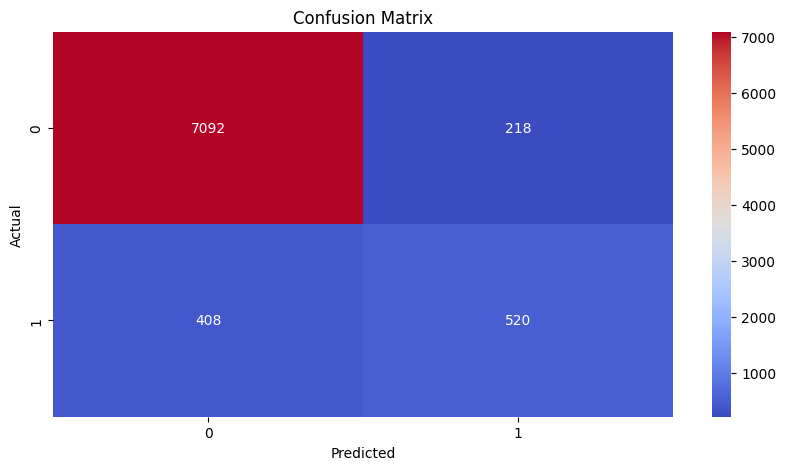

In [ ]:
plt.figure(figsize=(10,5))
confusionmatrix = confusion_matrix(y_test_binary,y_pred_labels_binary)
sns.heatmap(confusionmatrix,annot=True,fmt='d',cmap='coolwarm')
plt.title(f"Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Hyperparameter Tuning**

In [ ]:
pipeline_rf = Pipeline(steps=[
    ('preprocessor',preprocessor_new),
    ('classifier',RandomForestClassifier(random_state=42))
])
param_grid = {
    'classifier__n_estimators' : [100,200,300],
    'classifier__max_depth' : [None,10,20,30],
    'classifier__min_samples_split' : [2,5,10],
    'classifier__min_samples_leaf' : [1,2,4]
}
grid_search = GridSearchCV(
    estimator = pipeline_rf,
    param_grid = param_grid,
    cv = 5,
    scoring='f1',
    n_jobs=-1,
    verbose = 1
)

grid_search.fit(X_train,y_train)



Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipelin...
                                                                         Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20, 30],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='f1', verbose=1)

In [ ]:
# Choose the best model and best parameter
best_rf = grid_search.best_estimator_
print("Best Parameters:",grid_search.best_params_)

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


**Plot for Precision and Recall**

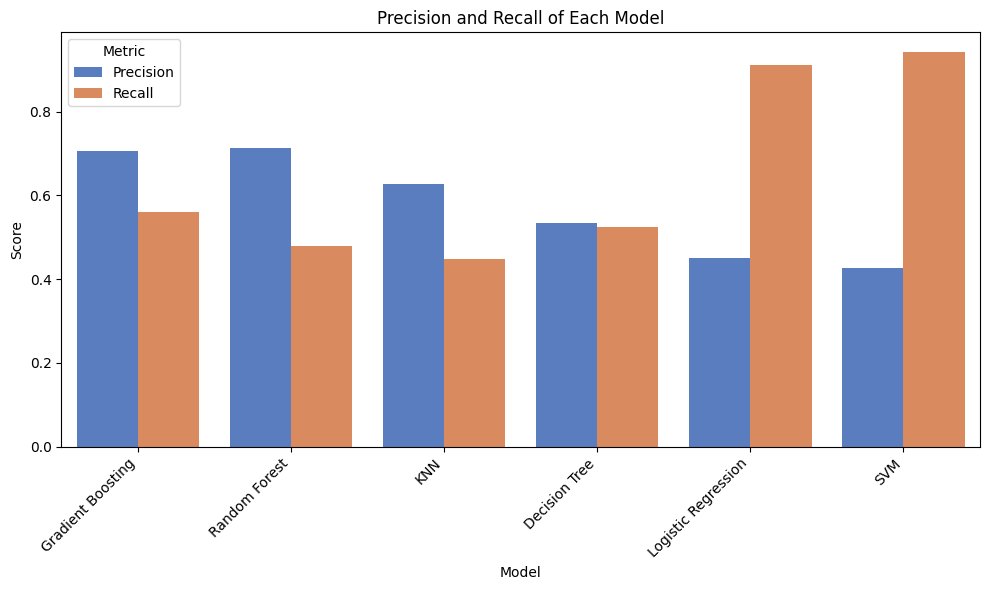

In [ ]:
plt.figure(figsize=(10,6))
metrics_melted = results_df.melt(id_vars='Model',value_vars=['Precision','Recall'],
                               var_name='Metric',value_name='Score')
sns.barplot(x='Model',y='Score',hue='Metric',data=metrics_melted,palette='muted')
plt.title("Precision and Recall of Each Model")
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45,ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

**Bar plot based on AUC Scores of Each model**

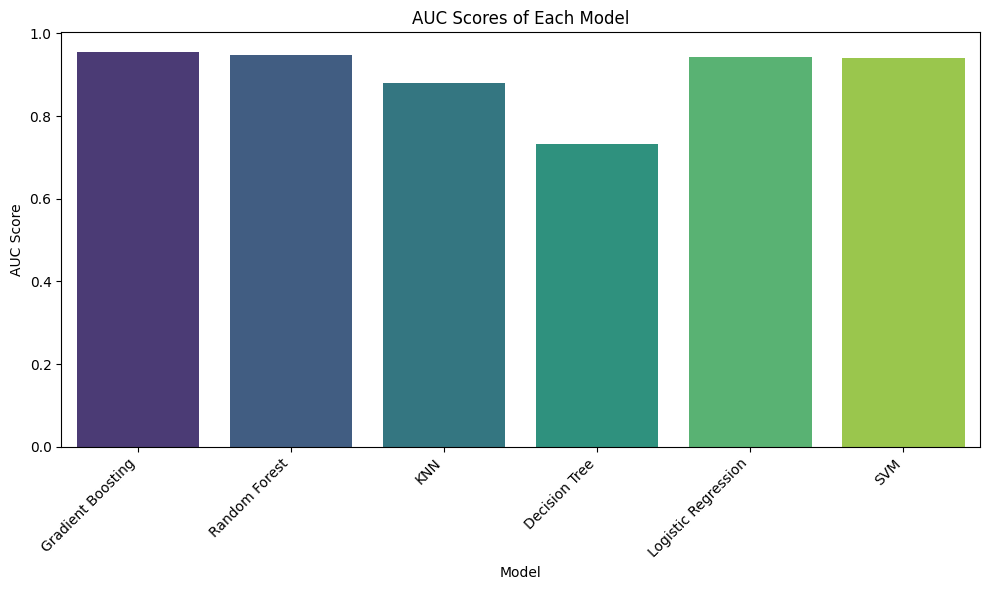

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Model',y='roc_auc',data=results_df,palette = 'viridis')
plt.title("AUC Scores of Each Model")
plt.xlabel('Model')
plt.ylabel('AUC Score')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

**Feature Importance**

In [ ]:
preprocessor_1 = pipeline.named_steps['preprocessor']
feature_names_transformed = preprocessor_1.get_feature_names_out()
gb_model = pipeline.named_steps['model']
feature_importances = gb_model.feature_importances_
feature_importance_df = pd.DataFrame({
  'Feature': feature_names_transformed,
  'Importance': feature_importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance',ascending=False)
print("Top 10 Feature Importances of Gradient Boosting:")
display(feature_importance_df.head(10))

Top 10 Feature Importances of Gradient Boosting:


,Feature,Importance
1,num__duration,0.470914
9,num__nr.employed,0.249134
8,num__euribor3m,0.089789
3,num__pdays,0.049588
7,num__cons.conf.idx,0.029359
62,cat__poutcome_success,0.015215
6,num__cons.price.idx,0.013537
53,cat__month_oct,0.012525
0,num__age,0.011716
50,cat__month_mar,0.009579


**Lollipop Plot for Feature Importance**

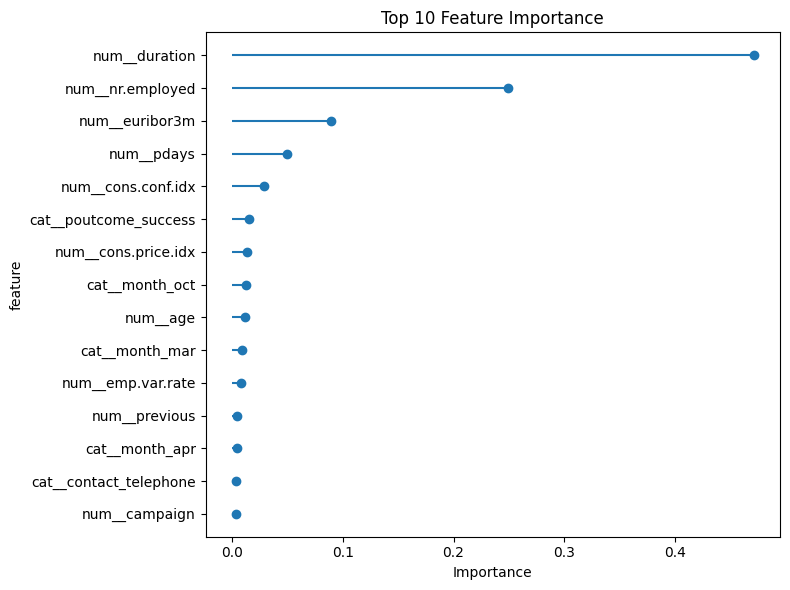

In [ ]:
plt.figure(figsize=(8,6))
top_features = feature_importance_df.head(15).sort_values("Importance")
plt.hlines(y=top_features["Feature"],
           xmin=0,
           xmax = top_features["Importance"])

plt.scatter(top_features['Importance'],
            top_features['Feature'])
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("feature")
plt.tight_layout()
plt.show()

**Final Model Selection**

Gradient Boosting Classifier was selected as the final model based on the  metrics like (ROC-AUC,precision,Recall and Accuracy).This model has achieved the super good ROC-AUC socre ~0.95 and this also provides the best overall balance and high precision(70.5%) which increases it's business value.

**Challenges Faced**

* Class Imbalance
* Outliers Hanlding
* Feature Engineering Complexity
* Precision and Recall Trade-off
* Model interpretability vs it's performance






**Conclusion**
The Gradient Boosting Classifier emerged as the super good model for predicting term deposit subscriptions in this portuguese bank marketing compaign with a ROC-AUC 0f 95.51% and balanced precision-recall performance.
The analysis revealed that economic indicators and previous campaign success are the most powerful predictors,offering clear guidance for future marketing strategies.